# Detecção de Fraudes em Transações Financeiras - Um projeto do curso DIO/Accenture.

### Desenvolvido por Lucas Rodrigues.

Este projeto foi desenvolvido como parte do Curso - "Python para Análise e Automação de Dados" com o objetivo construir um sistema de ML capaz de identificar transações fraudulentas em cartões de crédito.


---

O objetivo vai ser desenvolver um modelo preditivo que consiga identificar transações legítimas e diferencia-las de transações fraudulentas. Será utilizado um dataset onde apenas 0,17% das transações são fraudes.


---

Fraudes em transações financeiras representam um problema '**BI**'lionário para as instituições.
As perdas globais com fraudes em cartões são grandiosas e um número que já era grande está aumentando graças a presença da IA.

Defini alguns paramêtros que o sistema de detecção precisa atender:
   - 1 - Analisar transações em tempo real.
   - 2 - Minimizar falsos positivos (não bloquear compras legítimas obviamente).
   - 3 - Maximizar a detecção de fraudes reais.
   - 4 - Ser explicável, já que métricas sem explicações são apenas números sem sentido.

   
---

## Dataset

**Fonte utilizada no projeto:** [Credit Card Fraud Detection - Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

O dataset contém transações de cartões de crédito europeus realizadas em **SET/2013**.

## Característica / Valor

- Total de transações     = 284.807
- Transações fraudulentas = 492 (0,17%)
- Transações normais      = 284.315 (99,83%)
- Features                = 30 variáveis
- Target                  = Class (0=Normal, 1=Fraude)

### Desafios Identificados:

1. **Desequilíbrio**:
   - Um modelo que acusa normalidade para todas as transações teria 99,99% de Accuracy, mas não teria utilidade.
   - Vamos utilizar as métricas mais comuns para o caso sendo elas: Accuracy, Precision, Recall e F1-score.

2. **PCA**
   - Graças a compressão de dados do PCA utilizando matemática para compilar os componentes principais das transações, as colunas V1 á V28 estão comprimidas e não é possível interpretá-las diretamente.
   - Apenas `Time` e `Amount` são interpretáveis

3. **Custo dos erros**
   - Falso negativo = deixar passar uma fraude !!! custo altíssimo
   - Falso positivo = bloquear compra legítima  ! custo moderado (cliente insatisfeito)


---

##  Método

O projeto segue o fluxo padrão de um pipeline de Machine Learning:

1. Análise Exploratória (EDA) → Entender os dados
2. Pré-processamento          → Preparar as features
3. Treinamento de Modelos     → Logistic Regression, Random Forest, XGBoost
4. Avaliação Comparativa      → Métricas adequadas para desbalanceamento
5. Explicabilidade (SHAP)     → Entender as decisões do modelo


---

## Tecnologias Utilizadas

- **Python**
- **Pandas** → Manipulação de dados
- **NumPy** → Operações matemáticas
- **Scikit-learn** → Machine Learning clássico
- **XGBoost** → Gradient Boosting
- **SHAP** → Explicabilidade de modelos
- **Matplotlib & Seaborn** → Visualização de dados


---



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


## Feature Engineering

Antes de treinar os modelos, vou criar novas features para melhorar a performance.

### Coluna `Amount`

A coluna `Amount` está com a distribuição bem assimétrica:
- A maioria das transações está entre R$0,00 e R$500,00
- Poucas transações são acima de R$5.000

Isso pode prejudicar alguns modelos tipo o Logistic Regression, que assumem distribuição normal das features.

### Estratégia:
1. Transformação Logarítmica (`amount_log`):
    - Compacta os valores grandes: O impacto de valores gigantescos é drasticamente reduzido.
    - Expande os valores pequenos: A diferença entre valores menores ganha mais destaque e detalhe.
2. Padronização (`amount_scaled`):
    - Transforma a média de todas as colunas em 0 e o desvio padrão 1, valores que eram originalmente menores que a média viram números negativos, e valores que eram maiores viram números positivos.
    - Um valor com a média 2 significa que aquele dado está 2 desvios padrão acima da média.

In [5]:
# Transformação da coluna "Amount" (valores)

# 1- Transformação Logarítmica
# "log1p" ? ele faz log(1 + x), evitando problemas com valores zero

df['amount_log'] = np.log1p(df['Amount'])

In [6]:
# 2- Padronização com StandardScaler
# StandardScaler transforma os dados para ter média=0 e desvio padrão=1

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['amount_scaled'] = scaler.fit_transform(df[['Amount']])

## Preparação dos Dados

### Divisão Train/Test

Vamos dividir os dados em:
- Treino (70%): Para o modelo aprender
- Teste (30%): Para avaliar a performance

### Por que usar `stratify=y`?

O dataset tem só 0.17% de fraudes. Sem estratificação(divisão em camadas), poderíamos ter:
- Conjuntos de teste sem nenhuma fraude (impossível avaliar)
- Conjuntos de treino com poucas fraudes (modelo não aprende)

A estratificação garante que ambos os conjuntos mantenham a proporção original de classes.

In [7]:
# Preparação dos Dados - Train/Test Split

from sklearn.model_selection import train_test_split

# Separando features (X) e target (y)
# Removemos 'Class' (target) e 'Amount' (já temos amount_log e amount_scaled)

x = df.drop(['Class', 'Amount'], axis=1)
y = df['Class']

# Divisão estratificada

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    stratify=y, # Mantém proporção das classes
    test_size=0.3, # 30% para teste
    random_state=42 # Para reprodutibilidade
    )

print("=" * 19)
print(" DIVISÃO DOS DADOS")
print("=" * 19)
print(f"\n Conjunto de Treino: \n")
print(f"   - Amostras: {x_train.shape[0]:,}")
print(f"   - Fraudes: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"   - Normais: {len(y_train) - y_train.sum():,}")

print(f"\n Conjunto de Teste: \n")
print(f"   - Amostras: {x_test.shape[0]:,}")
print(f"   - Fraudes: {y_test.sum()} ({y_test.mean()*100:.4f}%)")
print(f"   - Normais: {len(y_test) - y_test.sum():,}")

print(f"\n Proporções parecidas em ambos = bom!")
print(f" Diferença na proporção de fraudes: {abs(y_train.mean() - y_test.mean())*100:.6f}%")

 DIVISÃO DOS DADOS

 Conjunto de Treino: 

   - Amostras: 199,364
   - Fraudes: 344 (0.1725%)
   - Normais: 199,020

 Conjunto de Teste: 

   - Amostras: 85,443
   - Fraudes: 148 (0.1732%)
   - Normais: 85,295

 Proporções parecidas em ambos = bom!
 Diferença na proporção de fraudes: 0.000666%


# Logistic Regression

## Modelo 1: Logistic Regression

### Logistic Regression

Modelo mais simples. Serve como Baseline.

### Métricas para Dataset Desbalanceado

Para Datasets desbalanceados NÃO use Accuracy! um modelo que sempre escolhe focar na classe com o "valor maior" pra tudo pode passar nos testes de Acurácia mesmo não fazendo seu papel.

Vamos focar em:
- Recall: Das fraudes reais, quantas detectamos? (quanto mais achar, melhor)
- Precision: Das fraudes detectadas, quantas são reais?
- F1-Score: Média harmônica entre Precision e Recall
- ROC-AUC: Capacidade do modelo de distinguir as classes

In [27]:
# LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Treinando o modelo
# max_iter=1000

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(x_train_scaled, y_train) # Usando a versão escalonada

# Fazendo previsões

y_pred_lr = model_lr.predict(x_test_scaled)
y_probs_lr = model_lr.predict_proba(x_test_scaled)[:, 1]  # probabilidade é de que 1 = fraude

# Avaliação

print("=" * 43)
print("LOGISTIC REGRESSION - CLASSIFICATION REPORT")
print("=" * 43)
print(classification_report(y_test, y_pred_lr))


# ROC = relação entra True Positive(Recall) e False Positive
# AUC = medição da qualidade do modelo sendo 0.6 ou < = ruim /// 0.7 ou > = bom podendo ser até mesmo perfeito caso atinja 1.0

# Calculando AUC
auc = roc_auc_score(y_test, y_probs_lr)
print(f"\n ROC-AUC: {auc:.4f}")
print(" (Quanto mais próximo de 1, melhor)")

print("=" * 43)
# Nota: O "ConvergenceWarning" aparece porque o "max_iter" atingiu o limite definido de 1000

LOGISTIC REGRESSION - CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.61      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443


 ROC-AUC: 0.9569
 (Quanto mais próximo de 1, melhor)


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.67      0.75       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



### Curva ROC (Receiver Operating Characteristic)

A curva ROC mostra a relação entre:
- True Positive Rate (Recall): Fraudes corretamente detectadas
- False Positive Rate: Transações normais classificadas erroneamente como fraude

AUC (Area Under Curve):
- AUC = 0.5 pra baixo = RUIM
- AUC = 0.7 - 1.0 = BOM até EXCELENTE

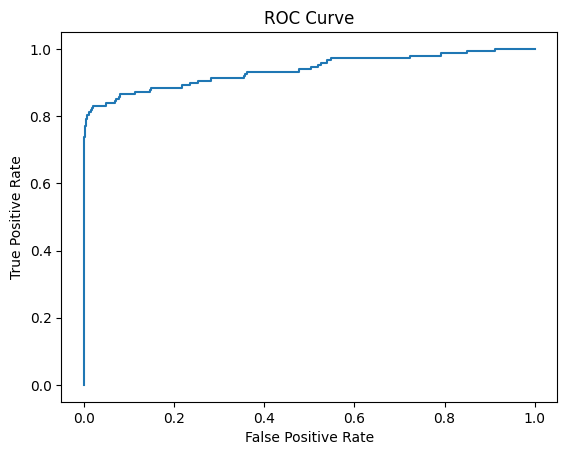


 AUC: 0.9369407129152718


In [10]:
# CURVA ROC
# Calculando FPR, TPR e thresholds

from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, y_probs_lr)

# Criando o gráfico

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print('\n AUC:', roc_auc_score(y_test, y_probs_lr))

# Modelo com 0.93, aparentemente um valor excelente

## Precision-Recall Curve

Agora vou analisar a Precision-Recall Curve, que é mais informativa que a ROC
para datasets desbalanceados como o usado (0,17% de fraudes).

### Por que PR Curve e não só ROC?

- A ROC Curve usa o False Positive Rate (FPR) no eixo X, que é calculado como `FP / (FP + TN)`.
- Como temos MUITOS negativos (transações normais), o FPR fica artificialmente baixo,
  mascarando o impacto real dos falsos positivos.
- A **PR Curve** foca apenas nos positivos previstos: `Precision = TP / (TP + FP)`.
- O que nos leva a pergunta "Das transações que bloqueei, quantas eram fraude de verdade?"

### O gráfico mostra:

- Eixo X (Recall): Das fraudes reais, quantas eu detectei?
- Eixo Y (Precision): Das que eu classifiquei como fraude, quantas eram reais?
- Curva descendente: Quanto mais eu tento pegar fraudes (recall alto), mais eu
  acabo bloqueando compras legítimas (precision cai).
- Ponto ideal: Canto superior direito (recall e precision altos ao mesmo tempo).

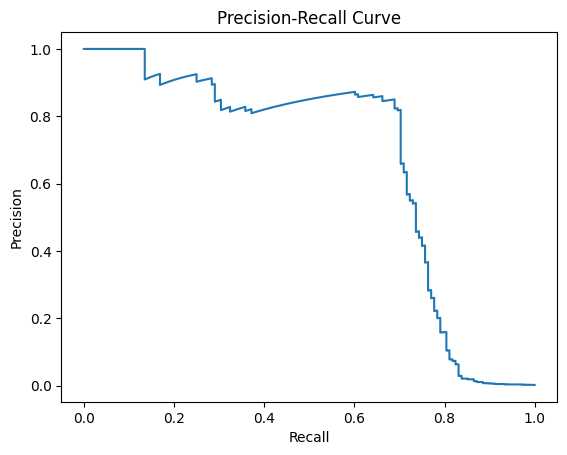

In [11]:
from sklearn.metrics import precision_recall_curve

# Essa métrica é provavelmente a mais IMPORTANTE para fraudes, pois não é afetada pelo
# enorme número de transações normais (como acontece com a ROC Curve).

precision, recall, thresholds = precision_recall_curve(y_test, y_probs_lr)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Com o recall acima de 0.70 o modelo tem dificuldade em analisar as fraudes e acaba bloqueando as transações legítimas...
# Porém com o recall de 0.15 até 0.70 ele detecta mais fraudes e a precision se mantém alta.


In [12]:
threshold = 0.3 # Define o valor mínino de 30% ao invés dos 50% padrão

y_pred_custom = (y_probs_lr > threshold).astype(int)

# Converte probabilidades em classes binárias:
# Se a probabilidade for > 0.3 → classifica como fraude (1)
# caso probabilidade <= 0.3 → classifica como normal (0)


print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.82      0.70      0.76       148

    accuracy                           1.00     85443
   macro avg       0.91      0.85      0.88     85443
weighted avg       1.00      1.00      1.00     85443



# Balanceamento de dados

## Opção 1: Undersampling

### Como funciona?
O Undersampling basicamente reduz a quantidade da classe majoritária (transações normais) até que ela se iguale à classe minoritária (fraudes).


Como temos 492 fraudes e 284.315 transações normais, o Undersampling vai 'Descartar Aleatoriamente' a maioria das transações normais, mantendo apenas 492 delas. No final, teremos um dataset com 984 linhas (492 de cada).

### ️ Prós e Contras:
- Prós: O modelo para de ser "preguiçoso" e é forçado a aprender a diferença real entre as classes.
- Contras: Perde muita informação. Jogamos fora mais de 280.000 transações normais que poderiam ajudar o modelo a entender o que é um comportamento "normal".

In [13]:
# Undersampling
# Primeiro filtramos as fraudes que são = "1"
fraudes = df[df['Class'] == 1]

# Depois filtramos as transações comuns = "0"
comuns = df[df['Class'] == 0].sample(len(fraudes), random_state=42)

# Juntamos/concatenamos os dois em um só
df_under = pd.concat([fraudes, comuns])

# vamos misturar os dados obtidos
df_under = df_under.sample(frac=1, random_state=42).reset_index(drop=True)

print(f" dataset novo: {df_under.shape}")
print(f"\nDistribuição:\n{df_under['Class'].value_counts()}")

 dataset novo: (984, 33)

Distribuição:
Class
0    492
1    492
Name: count, dtype: int64


## Opção 2: Oversampling com SMOTE


### Como o SMOTE funciona?
Em vez de jogar dados fora, o SMOTE (Synthetic Minority Over-sampling Technique) cria novas amostras sintéticas da classe minoritária.


1. Ele pega uma transação de fraude real.
2. Encontra as fraudes parecidas.
3. Cria uma "fraude sintética" em um ponto aleatório na linha reta entre essas duas fraudes.

### Nunca aplique SMOTE no dataset inteiro antes do `train_test_split`!
 Isso causa vazamento de dados. O SMOTE deve ser aplicado apenas no conjunto de treino = (`x_train`, `y_train`). O conjunto de teste deve permanecer com a distribuição real do mundo.


- O Scikit-learn não tem SMOTE nativo, por isso usamos a biblioteca "imblearn"

In [14]:
# Oversampling
# Vamos importar o SMOTE
from imblearn.over_sampling import SMOTE


# Criar o obj SMOTE
smote = SMOTE(random_state=42)

# E aplicar o SMOTE APENAS no conjunto de TREINO.
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

# Conjunto de teste
x_test_res = x_test
y_test_res = y_test

print(f"Formato de treino SMOTE: {x_train_res.shape}")

print(f"Formato original: {x_train.shape}")

print(f"\nDistribuição original do treino:\n{y_train.value_counts()}")
print(f"\nNova distribuição do treino com SMOTE:\n{pd.Series(y_train_res).value_counts()}")



print(f"\nDistribuição do teste (real):\n{y_test.value_counts()}")


Formato de treino SMOTE: (398040, 31)
Formato original: (199364, 31)

Distribuição original do treino:
Class
0    199020
1       344
Name: count, dtype: int64

Nova distribuição do treino com SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64

Distribuição do teste (real):
Class
0    85295
1      148
Name: count, dtype: int64


# Treinamento de Modelo

### Modelo Intermediário - Random Forest

O Random Forest é um algoritmo de Ensemble Learning (Aprendizado em Conjunto) que combina múltiplas Árvores de Decisão (Decision Tree) para criar um modelo mais robusto e preciso.

### Como funciona?

1. Cria várias árvores de decisão (controlado por `n_estimators`)
2. Cada árvore recebe uma amostra aleatória dos dados de treino
3. Cada árvore faz uma "votação" sobre a classificação
4. Ele combina os Outputs (votos) e os combina para criar previsões mais certeiras.

### Por que Random Forest para fraudes?

- O modelo lida bem com dados/transações incomuns sem comprometer a análise geral.
- O modelo identifica quais características tem mais influência na detecção de uma possivel fraude(hora, valor, local, etc).
- Consegue lidar com grandes volumes de dados.

In [15]:
# O RandomForest não precisa de dados normalizados.

from sklearn.ensemble import RandomForestClassifier

# Depois de importar o modelo, vamos definir os parâmetros a serem seguidos.

rf = RandomForestClassifier(
    n_estimators=50, # Cinquenta arvores de decisão
    max_depth=10, # Dez perguntas por arvore
    class_weight='balanced', # Ajuste das classes, dando mais ênfase as fraudes
    n_jobs=1,
    random_state=42
)

rf.fit(x_train, y_train)

# Agora dentre as cinquenta arvores, todas estão aprendendo diferentes padrões

y_pred_rf = rf.predict(x_test)

# O modelo vai analisar os padrões e retornar a decisão tomada pela maioria

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.76      0.80       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



### Modelo Avançado - XGBoost

O XGBoost (Extreme Gradient Boosting) é um dos algoritmos mais potentes para problemas desbalanceamento... Frequentimento usado nas competições do Kaggle, já que é otimizado para performance computacional.

### Como Funciona ?

1. Possui o parâmetro `scale_pos_weight` para lidar com classificações desbalanceadas
2. Supera outros algoritmos em datasets estruturados
3. Tem mecanismos nativois para prevenir o overfitting automaticamente
4. Possui a Feature importance nativa o que permite ele entender quais variáveis mais importam.



A expectativa é que o XGBoost supere a LogisticRegression em:
- Recall: Detectar mais fraudes reais
- F1-Score: Melhor equilíbrio entre precisão e recall
- AUC-ROC: Melhor capacidade de discriminação

In [16]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10, # aumenta o peso da classe minoritária (fraudes) em x10.
    eval_metric='logloss', # mede as previsões, penalizando previsões erradas feitas com muita confiança.
)

# O XGBoost vai criar várias árvores sequencialmente, cada uma corrige os erros da anterior e assim por diante.
xgb.fit(x_train, y_train)

# e então vai classificar caso seja 0:normal ou 1:fraude

y_pred_xgb = xgb.predict(x_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



# Organizando o Fluxo de Trabalho

### Pipeline
O Pipeline encapsula todas as etapas em um objeto só, e isso garante que o mesmo pré-processamento seja aplicado automaticamente nos dados de treino/teste.

### Algumas vantagens são:

- O `fit` só é chamado nos dados de treino.
- Graças ao encapsulamento podemos utilizar uma linha para treinar e uma linha para prever.
- A reprodutibilidade opera no mesmo fluxo em treino, teste e produção.
- Com o GridSearch podemos ajustar os hiperparâmetros de todas as etapas juntas.


In [17]:
from sklearn.pipeline import Pipeline

# Com o Pipeline importado, podemos unir múltiplas etapas de transformação e modelagem.

pipeline = Pipeline([
    ('scaler', StandardScaler()), # Padronizando os dados
    ('model', LogisticRegression(max_iter=1000)) # Treinando o modelo de LogisticRegression
])

# Usamos a Tupla(1 , 2) para definir os elementos sendo 1:nome(string) e 2:objeto(modelos ou transformers)
# max_iter com 1000 novamente (o padrão é 100, mas são muitos dados e tem a questão do ConvergenceWarning)

pipeline.fit(x_train, y_train)

# Ele aplica o fit_transform do StandardScaler nos dados de treino e também o fit da LogisticRegression nos dados já escalados.
# Importante: O fit do scaler só é chamado nos dados de treino, e isso evita Data Leakage.

y_pred = pipeline.predict(x_test)

# O resultado geralmente vai ser o mesmo de outros modelos que utilizam o StandardScaler e o LogisticRegression pois o modelo apenas organiza as etapas de forma mais segura e simples.

# É melhor utilizar ele quando há varias etapas de pré-processamento.

# Importância das Variáveis

### Importância das Variáveis = Feature Importance

Após treinar o modelo XGBoost, é fundamental entender quais features o modelo está usando para tomar as decisões.

### E como o XGBoost calcula isso?

Bom, por padrão, o XGBoost calcula a importância com base no Ganho, isso mede a melhoria relativa trazida por uma feature em todas as árvores do modelo. Quanto maior o valor, mais aquela variável contribuiu para separar as transações normais das fraudulentas.


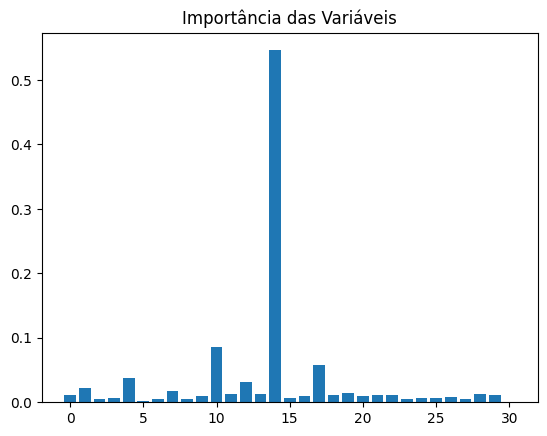

In [18]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

# o modelo vai apontar a variavel que mais influencia na medição

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das Variáveis")
plt.show()

# Ajuste de Hiperparâmetros

## Ajuste de Hiperparâmetros (Grid Search)

Até agora, usamos valores padrão ou "advinhados" (como `max_depth=10` ou `scale_pos_weight=10`). O Ajuste de Hiperparâmetros é o processo de encontrar a combinação exata de configurações que faz o modelo ter uma melhor performance.

### O que é o GridSearchCV?
O `GridSearchCV` (Grid Search com Validação Cruzada) é uma ferramenta que testa todas as combinações possíveis dos parâmetros que definimos e escolhe a melhor com base em uma métrica específica.

### Por que otimizamos pelo `scoring="recall"`?
Lembre-se do nosso objetivo de negócio: é muito pior deixar uma fraude passar (Falso Negativo) do que bloquear uma compra legítima por engano (Falso Positivo).
Portanto, instruímos o GridSearch a encontrar a combinação de parâmetros que maximize o Recall (a capacidade de detectar o máximo de fraudes reais), mesmo que a Precision caia um pouco.

### Como funciona a Validação Cruzada (`cv=3`)?
Em vez de treinar e testar apenas uma vez, o `cv=3` divide nossos dados de treino em 3 partes (folds). Ele treina em 2 partes e valida na 3ª, repetindo esse processo 3 vezes. Isso garante que o modelo está realmente aprendendo padrões gerais, e não apenas "decorando" um pedaço específico dos dados (evitando *overfitting*).

In [21]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(x_train, y_train)

print("Modelo melhor:", grid.best_params_)

# Utilizei GridSearchCV otimizando a métrica de Recall, o que deixa o comportamento do modelo mais proximo da realidade.
# Já que minimizar falsos negativos é a prioridade.

Modelo melhor: {'max_depth': 5, 'n_estimators': 100}


# Explicabilidade (SHAP)

## Explicabilidade do Modelo com SHAP

### SHAP
SHAP (SHapley Additive exPlanations) é baseada na Teoria dos Jogos para explicar a saída de qualquer modelo de Machine Learning. Ele conecta a atribuição de crédito ideal (Valores de Shapley) com explicações locais.

### Por que usar SHAP e não apenas a "Importância das Variáveis" do XGBoost?
A importância padrão do XGBoost (`feature_importances_`) pode ser inconsistente e enganosa. O SHAP resolve isso porque é matematicamente consistente: se o modelo se torna mais dependente de uma feature, o valor SHAP dessa feature nunca diminui.

### O que o SHAP responde?
- Explicabilidade Global: "Quais features são mais importantes para o modelo como um todo?" (É o que o gráfico de barras abaixo mostra).
- Explicabilidade Local: "Por que o modelo classificou esta transação específica como fraude?" (Mostra quanto cada feature empurrou a previsão para cima ou para baixo naquele caso exato).

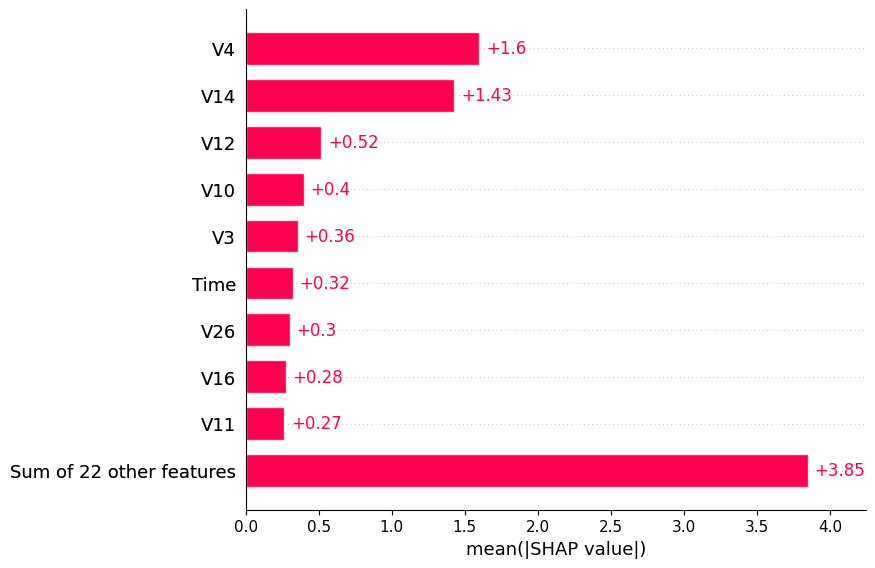

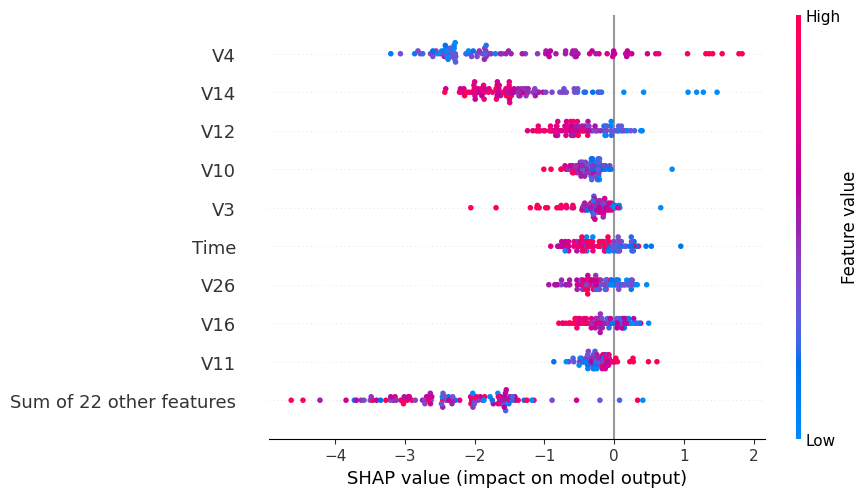

In [26]:
import shap

explainer = shap.Explainer(xgb)

# O SHAP é inteligente e detecta que o modelo é baseado em arvores de decisão.

shap_values = explainer(x_test[:100])

# Vamos usar uma amostra de 100 instâncias porque é suficiente para gerar um gráfico de barras confiável, sem travar meu notebook.

shap.plots.bar(shap_values)

# Quanto maior a barra, mais aquela feature impacta a decisão do modelo (seja para fraude ou transações normais)


print("=" * 114)
# Gráfico de resumo (Beeswarm plot) - Mostra direção e magnitude do impacto
# Vermelho = valor alto da feature, Azul = valor baixo da feature
shap.plots.beeswarm(shap_values)